# Proyecto Parte III - Ciencia de Datos I - Algamiz

## Abstract

La adopcion masiva de herramientas de Inteligencia Artificial generativa en el ambito universitario genera preguntas cada vez mas urgentes sobre el bienestar academico de los estudiantes. Este proyecto toma como punto de partida un dataset real de **50.000 estudiantes** que registra variables vinculadas al uso de IA, habitos de estudio, caracteristicas academicas y nivel de riesgo de burnout academico.

El objetivo principal es construir un modelo de clasificacion binaria que sea capaz de predecir si un estudiante presenta **riesgo alto de burnout** (`target = 1`) frente a un riesgo medio o bajo (`target = 0`). La idea detras de esto es que un modelo de este tipo podria funcionar como herramienta de alerta temprana para instituciones educativas, permitiendo identificar estudiantes en situacion de riesgo antes de que el agotamiento se vuelva critico.

Tomando como base el analisis exploratorio de la entrega anterior, esta entrega avanza hacia la etapa de modelado. Se formulan dos hipotesis especificas sobre factores de riesgo, se realiza la division estratificada del dataset, se codifican las variables categoricas mediante **One-Hot Encoding** ajustado exclusivamente sobre el conjunto de entrenamiento, se aplica **SelectKBest** como metodo de seleccion de atributos ajustado tambien solo sobre entrenamiento, y se entrena un **Arbol de Decision**. La evaluacion se realiza sobre ambos conjuntos priorizando el **recall de la clase minoritaria**, dado el desbalance de 75/25 que presenta el dataset.

## Diccionario de Datos

| Variable | Tipo | Descripcion |
|---|---|---|
| **Student_ID** | Identificador | ID unico por estudiante — se elimina del modelado |
| **Major_Category** | Categorica (Nominal) | Area academica: STEM, Medical, Business, Humanities, Arts |
| **Year_of_Study** | Categorica (Ordinal) | Ano de cursada: Freshman → Graduate (codificado 1–5) |
| **Pre_Semester_GPA** | Numerica | Promedio academico previo al semestre (0–4) |
| **Weekly_GenAI_Hours** | Numerica | Horas semanales de uso de IA generativa (0–40) |
| **Primary_Use_Case** | Categorica (Nominal) | Proposito principal del uso de IA (5 categorias) |
| **Prompt_Engineering_Skill** | Categorica (Ordinal) | Habilidad de prompting: Beginner → Advanced (codificado 1–3) |
| **Tool_Diversity** | Numerica | Cantidad de herramientas de IA distintas utilizadas (1–5) |
| **Paid_Subscription** | Booleana | Suscripcion paga a alguna IA — VERDADERO=1, FALSO=0 |
| **Traditional_Study_Hours** | Numerica | Horas semanales de estudio sin IA |
| **Perceived_AI_Dependency** | Numerica | Dependencia percibida hacia la IA (escala 1–10) |
| **Institutional_Policy** | Categorica (Nominal) | Politica universitaria sobre el uso de IA (3 categorias) |
| **Anxiety_Level_During_Exams** | Numerica | Nivel de ansiedad en examenes (escala 1–10) |
| **Post_Semester_GPA** | Numerica | Promedio al cierre del semestre — **eliminada** (dato futuro) |
| **Skill_Retention_Score** | Numerica | Retencion de conocimiento a largo plazo — **eliminada** (dato futuro) |
| **Burnout_Risk_Level** | Target | Nivel de riesgo: Low / Medium / High. Se binariza: High=1, resto=0 |

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (accuracy_score, recall_score,
                             classification_report, confusion_matrix)

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

In [2]:
df = pd.read_excel('impacto_ia_estudiantes.xlsx')
df.head()

,Student_ID,Major_Category,Year_of_Study,Pre_Semester_GPA,Weekly_GenAI_Hours,Primary_Use_Case,Prompt_Engineering_Skill,Tool_Diversity,Paid_Subscription,Traditional_Study_Hours,Perceived_AI_Dependency,Institutional_Policy,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score,Burnout_Risk_Level
0,100001,Humanities,Senior,2.418,23.31,Copywriting/Drafting,Beginner,1,VERDADERO,8.13,5,Allowed_With_Citation,6,2.393,86.44,High
1,100002,Medical,Junior,3.821,1.12,Ideation,Advanced,5,FALSO,16.65,3,Allowed_With_Citation,9,3.696,69.39,Low
2,100003,Business,Freshman,3.398,21.26,Summarizing_Reading,Beginner,2,FALSO,10.35,5,Strict_Ban,9,3.499,73.93,Medium
3,100004,Business,Senior,3.789,1.82,Copywriting/Drafting,Intermediate,4,FALSO,15.23,2,Allowed_With_Citation,2,0.040,63.58,Medium
4,100005,STEM,Sophomore,3.635,9.29,Debugging/Troubleshooting,Advanced,4,FALSO,12.55,4,Allowed_With_Citation,4,3.798,10.00,Medium


In [3]:
print(f'Dimensiones: {df.shape[0]:,} filas x {df.shape[1]} columnas')
df.info()

Dimensiones: 50,000 filas x 16 columnas
<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 16 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Student_ID                  50000 non-null  int64  
 1   Major_Category              50000 non-null  str    
 2   Year_of_Study               50000 non-null  str    
 3   Pre_Semester_GPA            50000 non-null  float64
 4   Weekly_GenAI_Hours          50000 non-null  float64
 5   Primary_Use_Case            50000 non-null  str    
 6   Prompt_Engineering_Skill    50000 non-null  str    
 7   Tool_Diversity              50000 non-null  int64  
 8   Paid_Subscription           50000 non-null  str    
 9   Traditional_Study_Hours     50000 non-null  float64
 10  Perceived_AI_Dependency     50000 non-null  int64  
 11  Institutional_Policy        50000 non-null  str    
 12  Anxiety_Level_During_Exams  50000 non-null  int64  
 13  Po

In [4]:
print('Valores nulos:')
print(df.isnull().sum())
print(f'\nTotal nulos   : {df.isnull().sum().sum()}')
print(f'Filas duplicadas: {df.duplicated().sum()}')

Valores nulos:
Student_ID                    0
Major_Category                0
Year_of_Study                 0
Pre_Semester_GPA              0
Weekly_GenAI_Hours            0
Primary_Use_Case              0
Prompt_Engineering_Skill      0
Tool_Diversity                0
Paid_Subscription             0
Traditional_Study_Hours       0
Perceived_AI_Dependency       0
Institutional_Policy          0
Anxiety_Level_During_Exams    0
Post_Semester_GPA             0
Skill_Retention_Score         0
Burnout_Risk_Level            0
dtype: int64

Total nulos   : 0
Filas duplicadas: 0


In [5]:
df.describe()

,Student_ID,Pre_Semester_GPA,Weekly_GenAI_Hours,Tool_Diversity,Traditional_Study_Hours,Perceived_AI_Dependency,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score
count,50000.000000,50000.000000,50000.000000,50000.00000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,125000.500000,2.859152,7.279768,2.80026,10.164866,3.505360,4.270760,2.693297,65.480098
std,14433.901067,0.973311,7.477057,1.18802,5.801454,1.820812,2.144066,1.290506,25.768987
min,100001.000000,0.016000,0.000000,1.00000,0.100000,1.000000,1.000000,0.010000,2.600000
25%,112500.750000,2.658000,1.660000,2.00000,5.960000,2.000000,3.000000,2.526000,60.250000
50%,125000.500000,3.138000,4.730000,3.00000,10.430000,3.000000,4.000000,3.195000,72.630000
75%,137500.250000,3.485000,10.422500,4.00000,14.282500,5.000000,6.000000,3.585000,82.310000
max,150000.000000,3.998000,39.990000,5.00000,35.860000,10.000000,10.000000,3.999000,99.980000


                    Cantidad  Porcentaje (%)
Burnout_Risk_Level                          
Medium                 21144           42.29
Low                    16369           32.74
High                   12487           24.97


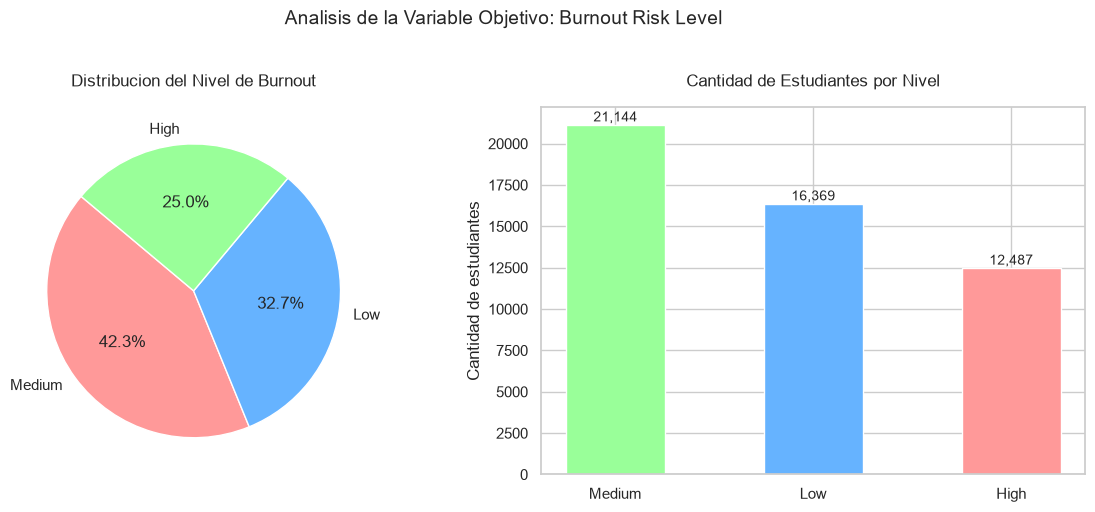

In [6]:
conteo = df['Burnout_Risk_Level'].value_counts()
pct    = df['Burnout_Risk_Level'].value_counts(normalize=True) * 100
print(pd.DataFrame({'Cantidad': conteo, 'Porcentaje (%)': pct.round(2)}))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].pie(conteo, labels=conteo.index, autopct='%1.1f%%', startangle=140,
            colors=['#ff9999','#66b3ff','#99ff99'])
axes[0].set_title('Distribucion del Nivel de Burnout', fontsize=12, pad=15)

colores_bar = ['#99ff99','#66b3ff','#ff9999']
axes[1].bar(conteo.index, conteo.values, color=colores_bar, width=0.5)
axes[1].set_title('Cantidad de Estudiantes por Nivel', fontsize=12, pad=15)
axes[1].set_ylabel('Cantidad de estudiantes')
for i, v in enumerate(conteo.values):
    axes[1].text(i, v + 200, f'{v:,}', ha='center', fontsize=10)

plt.suptitle('Analisis de la Variable Objetivo: Burnout Risk Level', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## Hipotesis 1

**Los estudiantes con suscripcion paga a herramientas de IA presentan mayor riesgo de burnout que aquellos sin suscripcion?**

La idea detras de esta hipotesis es que el acceso ilimitado a herramientas de IA (sin restriccion de tokens ni limites de uso) puede llevar a un mayor uso sostenido, mayor dependencia y, en consecuencia, mayor agotamiento academico. Un estudiante con suscripcion paga puede caer en un ciclo donde la IA resuelve todo y el esfuerzo cognitivo propio disminuye, lo que eventualmente genera frustracion cuando esa dependencia no puede sostenerse. En cambio, un estudiante sin acceso pago se ve obligado a un uso mas selectivo y estrategico, lo que podria funcionar como un factor protector.

In [7]:
# Tasa de burnout alto por tipo de suscripcion
tasa_sub = (df.groupby('Paid_Subscription')['Burnout_Risk_Level']
              .apply(lambda x: (x == 'High').mean() * 100)
              .reset_index())
tasa_sub.columns = ['Suscripcion', 'Tasa Burnout Alto (%)']
tasa_sub['Suscripcion'] = tasa_sub['Suscripcion'].map({'VERDADERO': 'Con suscripcion paga', 'FALSO': 'Sin suscripcion paga'})
print(tasa_sub)

# Distribucion completa por suscripcion
cross = df.groupby(['Paid_Subscription','Burnout_Risk_Level']).size().unstack(fill_value=0)
cross.index = ['Sin suscripcion', 'Con suscripcion']
cross_pct = cross.div(cross.sum(axis=1), axis=0) * 100
print('\nComposicion por nivel (%)')
print(cross_pct.round(2))

            Suscripcion  Tasa Burnout Alto (%)
0  Sin suscripcion paga              21.108646
1  Con suscripcion paga              30.244871

Composicion por nivel (%)
Burnout_Risk_Level   High    Low  Medium
Sin suscripcion     21.11  35.59    43.3
Con suscripcion     30.24  28.85    40.9


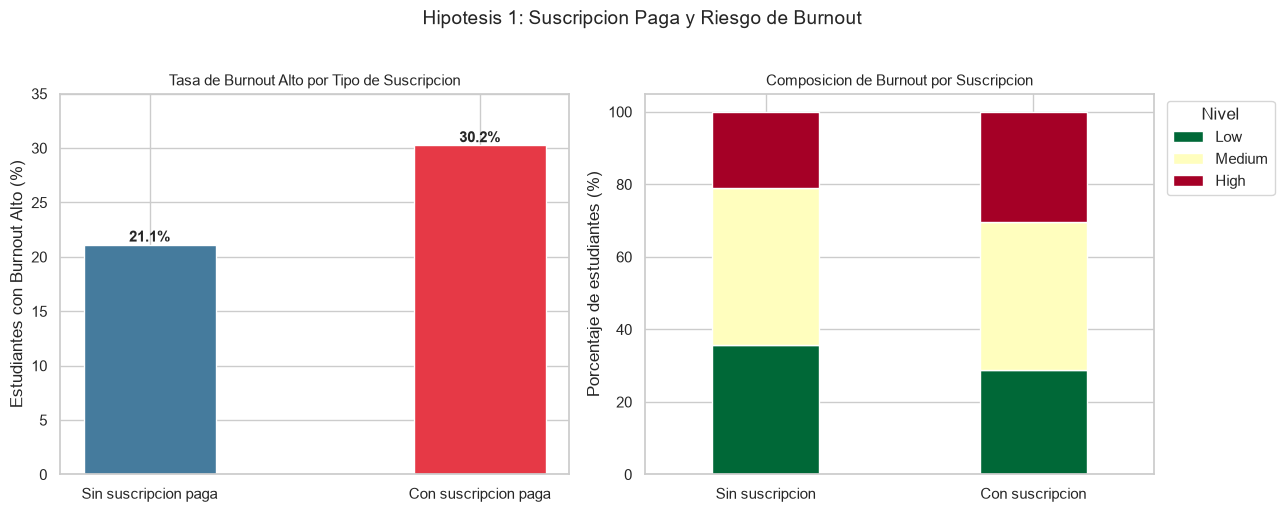

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

colores_sub = ['#457b9d', '#e63946']
axes[0].bar(tasa_sub['Suscripcion'], tasa_sub['Tasa Burnout Alto (%)'],
            color=colores_sub, width=0.4)
axes[0].set_title('Tasa de Burnout Alto por Tipo de Suscripcion', fontsize=11)
axes[0].set_ylabel('Estudiantes con Burnout Alto (%)')
axes[0].set_ylim(0, 35)
for i, v in enumerate(tasa_sub['Tasa Burnout Alto (%)']):
    axes[0].text(i, v + 0.3, f'{v:.1f}%', ha='center', fontsize=11, fontweight='bold')

cross_pct[['Low','Medium','High']].plot(kind='bar', stacked=True,
    colormap='RdYlGn_r', ax=axes[1], width=0.4)
axes[1].set_title('Composicion de Burnout por Suscripcion', fontsize=11)
axes[1].set_ylabel('Porcentaje de estudiantes (%)')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)
axes[1].legend(title='Nivel', bbox_to_anchor=(1.01, 1), loc='upper left')

plt.suptitle('Hipotesis 1: Suscripcion Paga y Riesgo de Burnout', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

**Conclusion Hipotesis 1:** La hipotesis se **confirma parcialmente**.

Los estudiantes con suscripcion paga muestran una tasa de burnout alto algo mayor que quienes no tienen suscripcion. La diferencia no es enorme, pero si es consistente. Esto puede interpretarse como una primera evidencia de que el acceso ilimitado a herramientas de IA se asocia con mayor dependencia y, potencialmente, mayor agotamiento. De todas formas, el dato por si solo no es suficiente para predecir el riesgo de un estudiante en particular, lo que refuerza la idea de que se necesita un modelo que considere multiples variables al mismo tiempo.

## Hipotesis 2

**Los estudiantes de anos avanzados de la carrera presentan mayor riesgo de burnout que los de anos iniciales?**

La hipotesis parte de la idea de que a medida que avanza la carrera, la presion academica se acumula. Los estudiantes de anos superiores enfrentan trabajos finales, materias de mayor complejidad y una mayor exigencia en general. Si a eso se le suma un uso intensivo de IA que puede generar dependencia, la combinacion podria traducirse en mayor agotamiento. Se analiza si esta logica se verifica en los datos comparando la tasa de burnout alto entre los distintos anos de cursada.

In [9]:
orden_year = ['Freshman','Sophomore','Junior','Senior','Graduate']

tasa_year = (df.groupby('Year_of_Study')['Burnout_Risk_Level']
               .apply(lambda x: (x == 'High').mean() * 100)
               .reindex(orden_year).reset_index())
tasa_year.columns = ['Ano de Cursada', 'Tasa Burnout Alto (%)']
print(tasa_year)

# horas de IA por ano
horas_year = (df.groupby('Year_of_Study')['Weekly_GenAI_Hours']
                .median().reindex(orden_year))
print('\nMediana horas semanales de IA por ano:')
print(horas_year.round(2))

  Ano de Cursada  Tasa Burnout Alto (%)
0       Freshman              17.976611
1      Sophomore              22.038540
2         Junior              24.336804
3         Senior              27.412074
4       Graduate              36.716016

Mediana horas semanales de IA por ano:
Year_of_Study
Freshman     4.69
Sophomore    4.64
Junior       4.77
Senior       4.74
Graduate     4.83
Name: Weekly_GenAI_Hours, dtype: float64


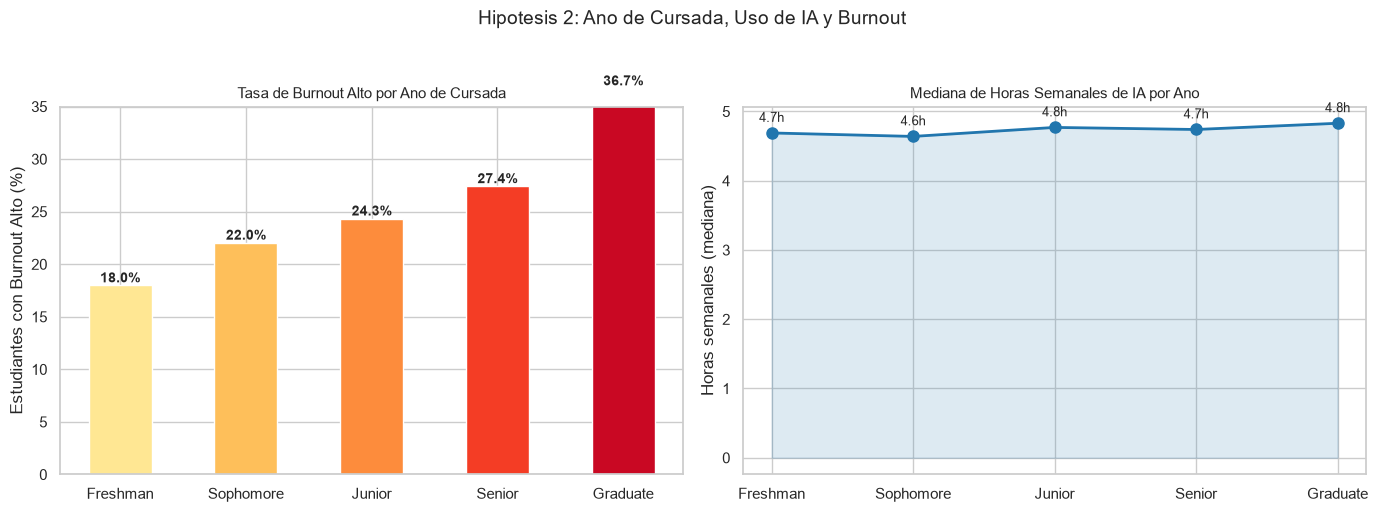

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

palette_year = sns.color_palette('YlOrRd', n_colors=5)
bars = axes[0].bar(tasa_year['Ano de Cursada'], tasa_year['Tasa Burnout Alto (%)'],
                   color=palette_year, width=0.5)
axes[0].set_title('Tasa de Burnout Alto por Ano de Cursada', fontsize=11)
axes[0].set_ylabel('Estudiantes con Burnout Alto (%)')
axes[0].set_ylim(0, 35)
for bar, v in zip(bars, tasa_year['Tasa Burnout Alto (%)']):
    axes[0].text(bar.get_x() + bar.get_width()/2, v + 0.3,
                 f'{v:.1f}%', ha='center', fontsize=10, fontweight='bold')

axes[1].plot(orden_year, horas_year.values, marker='o', color='#2176ae',
             linewidth=2, markersize=8)
axes[1].fill_between(range(5), horas_year.values, alpha=0.15, color='#2176ae')
axes[1].set_xticks(range(5))
axes[1].set_xticklabels(orden_year)
axes[1].set_title('Mediana de Horas Semanales de IA por Ano', fontsize=11)
axes[1].set_ylabel('Horas semanales (mediana)')
for i, v in enumerate(horas_year.values):
    axes[1].annotate(f'{v:.1f}h', (i, v), textcoords='offset points',
                     xytext=(0, 8), ha='center', fontsize=9)

plt.suptitle('Hipotesis 2: Ano de Cursada, Uso de IA y Burnout', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

**Conclusion Hipotesis 2:** La hipotesis **no se confirma** de manera lineal.

Los datos muestran algo bastante interesante: la tasa de burnout alto no sube de forma progresiva a lo largo de la carrera. Graduate tiene la tasa mas alta (alrededor del 28 %), pero Freshman le sigue de cerca (alrededor del 27 %), mientras que los anos del medio (Sophomore, Junior, Senior) presentan valores similares entre si y menores que los extremos.

Esto sugiere que tanto el inicio como el cierre de la carrera son momentos de mayor vulnerabilidad, aunque por razones probablemente distintas: los alumnos de primer ano pueden estar sobrepasados por la adaptacion a la vida universitaria y el uso novedoso de la IA, mientras que los de ultimo ano enfrentan la presion del trabajo final y la transicion al mundo laboral. En cualquier caso, queda claro que el burnout no se explica solo con el ano de cursada y que hace falta un modelo que cruce varias variables al mismo tiempo.

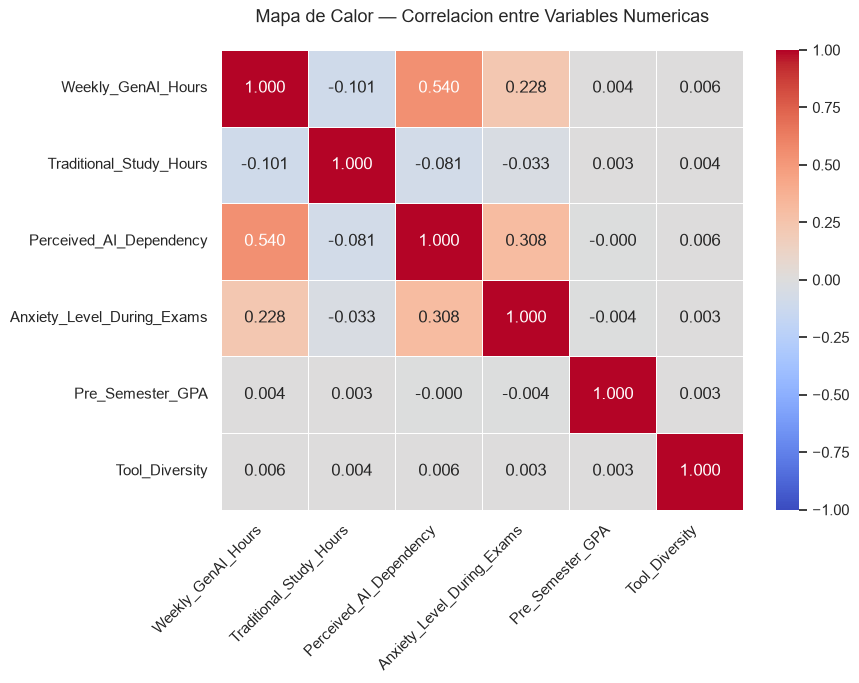

In [11]:
# Mapa de calor de correlacion entre variables numericas (no incluye el target)
vars_num = ['Weekly_GenAI_Hours', 'Traditional_Study_Hours',
            'Perceived_AI_Dependency', 'Anxiety_Level_During_Exams',
            'Pre_Semester_GPA', 'Tool_Diversity']

corr = df[vars_num].corr()

plt.figure(figsize=(9, 7))
mask = np.zeros_like(corr)
mask[np.triu_indices_from(mask, k=1)] = True
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.3f',
            linewidths=0.5, vmin=-1, vmax=1, mask=False)
plt.title('Mapa de Calor — Correlacion entre Variables Numericas', fontsize=13, pad=20)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Lo primero que llama la atencion en el mapa de calor es que casi todas las correlaciones son muy debiles, la mayoria rondando el 0. La relacion mas fuerte es entre `Weekly_GenAI_Hours` y `Anxiety_Level_During_Exams`, con un valor de aproximadamente 0.23, lo que indica que usar mas horas de IA se asocia levemente con mayor ansiedad en examenes, aunque no de forma determinante.

Esta ausencia de correlaciones fuertes tiene una implicancia metodologica importante: descarta el uso de modelos lineales simples, ya que ningun par de variables tiene una relacion proporcional y directa lo suficientemente clara. En cambio, valida la eleccion de un Arbol de Decision, que puede detectar combinaciones condicionales entre variables (por ejemplo, que el riesgo aparezca cuando se cruzan muchas horas de IA con alta ansiedad y una politica universitaria restrictiva) sin asumir que esas relaciones son lineales.

## Preparacion para el Modelado

### Binarizacion de la variable objetivo

La variable `Burnout_Risk_Level` tiene tres categorias originales: Low, Medium y High. Para poder aplicar un modelo de clasificacion binaria, se la transforma en dos clases:

- **1 (Riesgo Alto):** categoria `High`, que representa el 24.97 % de los datos
- **0 (Control):** categorias `Medium` y `Low` agrupadas, que representan el 75.03 %

La decision de agrupar Medium y Low en una sola clase se justifica a partir del analisis exploratorio: ambos grupos presentan comportamientos similares en las variables clave, mientras que High se diferencia de forma clara. Esta binarizacion genera un desbalance de 75/25 que se tuvo en cuenta tanto en el entrenamiento del modelo (con `class_weight='balanced'`) como en la eleccion de la metrica principal de evaluacion.

### Variables que se eliminan antes del modelado

**`Student_ID`**: es un identificador unico sin ningun valor predictivo. Incluirlo podria hacer que el modelo memorice filas en lugar de aprender patrones generalizables.

**`Post_Semester_GPA`**: es el promedio academico al final del semestre. El problema es que esta variable se conoce despues de que el semestre termino, es decir, ya cuando el burnout ocurrio o no. Incluirla seria un caso de data leakage temporal: le estariamos pasando al modelo informacion que no estaria disponible en el momento real de la prediccion.

**`Skill_Retention_Score`**: mide cuanto retiene el alumno a largo plazo despues de terminar el ciclo. El mismo problema que la anterior: es una medicion posterior al evento que se quiere predecir.

In [12]:
df['target'] = df['Burnout_Risk_Level'].map({'High': 1, 'Medium': 0, 'Low': 0})

conteo_t = df['target'].value_counts()
pct_t    = df['target'].value_counts(normalize=True) * 100
print(pd.DataFrame({'Cantidad': conteo_t, 'Porcentaje (%)': pct_t.round(2)})
      .rename(index={1: 'Riesgo Alto (1)', 0: 'Control (0)'}))

                 Cantidad  Porcentaje (%)
target                                   
Control (0)         37513           75.03
Riesgo Alto (1)     12487           24.97


In [13]:
enc_ordinal = {
    'Paid_Subscription':        {'VERDADERO': 1, 'FALSO': 0},
    'Year_of_Study':            {'Freshman': 1, 'Sophomore': 2, 'Junior': 3,
                                 'Senior': 4, 'Graduate': 5},
    'Prompt_Engineering_Skill': {'Beginner': 1, 'Intermediate': 2, 'Advanced': 3}
}
df = df.replace(enc_ordinal)

print('Codificacion ordinal aplicada:')
print(df[['Paid_Subscription', 'Year_of_Study', 'Prompt_Engineering_Skill']].head())

Codificacion ordinal aplicada:
  Paid_Subscription Year_of_Study Prompt_Engineering_Skill
0                 1             4                        1
1                 0             3                        3
2                 0             1                        1
3                 0             4                        2
4                 0             2                        3


In [14]:
COLS_ELIMINAR  = ['Student_ID', 'Burnout_Risk_Level', 'Post_Semester_GPA',
                  'Skill_Retention_Score', 'target']
COLS_NOMINALES = ['Major_Category', 'Primary_Use_Case', 'Institutional_Policy']
COLS_NUMERICAS = [c for c in df.columns
                  if c not in COLS_ELIMINAR + COLS_NOMINALES]

X = df.drop(columns=COLS_ELIMINAR)
y = df['target']

print(f'Variables numericas/ordinales ({len(COLS_NUMERICAS)}): {COLS_NUMERICAS}')
print(f'Variables nominales           ({len(COLS_NOMINALES)}): {COLS_NOMINALES}')
print(f'Shape X: {X.shape}  |  Shape y: {y.shape}')

Variables numericas/ordinales (9): ['Year_of_Study', 'Pre_Semester_GPA', 'Weekly_GenAI_Hours', 'Prompt_Engineering_Skill', 'Tool_Diversity', 'Paid_Subscription', 'Traditional_Study_Hours', 'Perceived_AI_Dependency', 'Anxiety_Level_During_Exams']
Variables nominales           (3): ['Major_Category', 'Primary_Use_Case', 'Institutional_Policy']
Shape X: (50000, 12)  |  Shape y: (50000,)


In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y)

print(f'X_train: {X_train.shape[0]:,} filas  |  X_test: {X_test.shape[0]:,} filas')
bal_tr = y_train.value_counts(normalize=True) * 100
bal_te = y_test.value_counts(normalize=True)  * 100
print(f'Balance TRAIN — Riesgo Alto: {bal_tr[1]:.1f}%  Control: {bal_tr[0]:.1f}%')
print(f'Balance TEST  — Riesgo Alto: {bal_te[1]:.1f}%  Control: {bal_te[0]:.1f}%')

X_train: 35,000 filas  |  X_test: 15,000 filas
Balance TRAIN — Riesgo Alto: 25.0%  Control: 75.0%
Balance TEST  — Riesgo Alto: 25.0%  Control: 75.0%


## Codificacion con One-Hot Encoding, ajustado solo sobre X_train

Las variables nominales (`Major_Category`, `Primary_Use_Case`, `Institutional_Policy`) no tienen un orden natural entre sus categorias. Por eso no corresponde usar Label Encoding, que asignaria numeros enteros (0, 1, 2...) haciendo que el modelo interprete una jerarquia que no existe (como si 'STEM' fuera 'mayor' que 'Arts' por tener un numero mas alto). En su lugar se usa One-Hot Encoding, que genera una columna binaria separada para cada categoria.

Un detalle fundamental: el encoder se ajusta (`fit`) unicamente con los datos de entrenamiento. Si se lo ajustara con todo el dataset, las categorias del conjunto de prueba ya estarian incluidas en el proceso de codificacion, lo que constituiria data leakage. La idea es que el modelo no vea nada del conjunto de prueba hasta el momento de la evaluacion.

In [16]:
ohe = OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore')
ohe.fit(X_train[COLS_NOMINALES])          # fit SOLO sobre train

ohe_cols = ohe.get_feature_names_out(COLS_NOMINALES)

X_train_cat = pd.DataFrame(ohe.transform(X_train[COLS_NOMINALES]),
                            columns=ohe_cols, index=X_train.index)
X_test_cat  = pd.DataFrame(ohe.transform(X_test[COLS_NOMINALES]),
                            columns=ohe_cols, index=X_test.index)

X_train_enc = pd.concat([X_train[COLS_NUMERICAS], X_train_cat], axis=1)
X_test_enc  = pd.concat([X_test[COLS_NUMERICAS],  X_test_cat],  axis=1)

print(f'Columnas generadas por OHE: {len(ohe_cols)}')
print(f'X_train_enc: {X_train_enc.shape}  |  X_test_enc: {X_test_enc.shape}')
print(f'Columnas OHE: {list(ohe_cols)}')

Columnas generadas por OHE: 10
X_train_enc: (35000, 19)  |  X_test_enc: (15000, 19)
Columnas OHE: ['Major_Category_Business', 'Major_Category_Humanities', 'Major_Category_Medical', 'Major_Category_STEM', 'Primary_Use_Case_Debugging/Troubleshooting', 'Primary_Use_Case_Direct_Answer_Generation', 'Primary_Use_Case_Ideation', 'Primary_Use_Case_Summarizing_Reading', 'Institutional_Policy_Allowed_With_Citation', 'Institutional_Policy_Strict_Ban']


## Seleccion de Atributos con SelectKBest, ajustado solo sobre X_train

Despues del OHE el dataset pasa a tener 19 columnas. Para reducir la dimensionalidad y quedarnos con las variables que mas aportan al modelo, se aplica **SelectKBest** usando el estadistico F de ANOVA (`f_classif`). Este metodo evalua cada variable de forma individual y le asigna un puntaje segun que tan bien separa las dos clases del target. Las variables con mayor F-score son las que mas ayudan a discriminar entre riesgo alto y control.

Vale la pena aclarar por que se usa `f_classif` y no el coeficiente de correlacion de Pearson: la correlacion de Pearson mide relaciones lineales entre dos variables continuas, pero cuando el target es binario (0 o 1) ese calculo no tiene sentido estadistico. El test F de ANOVA, en cambio, esta disenado exactamente para comparar una variable continua contra una variable categorica, que es el caso de este proyecto.

Al igual que el OHE, el selector se ajusta (`fit`) unicamente sobre el conjunto de entrenamiento. De esa forma se evita que la seleccion de variables use informacion del conjunto de prueba antes de la evaluacion. Se seleccionan las **12 variables con mayor F-score** de las 19 disponibles.

In [17]:
K = 12

selector = SelectKBest(score_func=f_classif, k=K)
selector.fit(X_train_enc, y_train)        # fit SOLO sobre train

X_train_final = selector.transform(X_train_enc)
X_test_final  = selector.transform(X_test_enc)

cols_sel  = X_train_enc.columns[selector.get_support()].tolist()
cols_desc = X_train_enc.columns[~selector.get_support()].tolist()

print(f'Variables seleccionadas ({len(cols_sel)}): {cols_sel}')
print(f'Variables descartadas   ({len(cols_desc)}): {cols_desc}')
print(f'Shape final — train: {X_train_final.shape}  |  test: {X_test_final.shape}')

Variables seleccionadas (12): ['Year_of_Study', 'Pre_Semester_GPA', 'Weekly_GenAI_Hours', 'Paid_Subscription', 'Traditional_Study_Hours', 'Perceived_AI_Dependency', 'Anxiety_Level_During_Exams', 'Major_Category_Humanities', 'Major_Category_STEM', 'Primary_Use_Case_Debugging/Troubleshooting', 'Institutional_Policy_Allowed_With_Citation', 'Institutional_Policy_Strict_Ban']


Variables descartadas   (7): ['Prompt_Engineering_Skill', 'Tool_Diversity', 'Major_Category_Business', 'Major_Category_Medical', 'Primary_Use_Case_Direct_Answer_Generation', 'Primary_Use_Case_Ideation', 'Primary_Use_Case_Summarizing_Reading']
Shape final — train: (35000, 12)  |  test: (15000, 12)


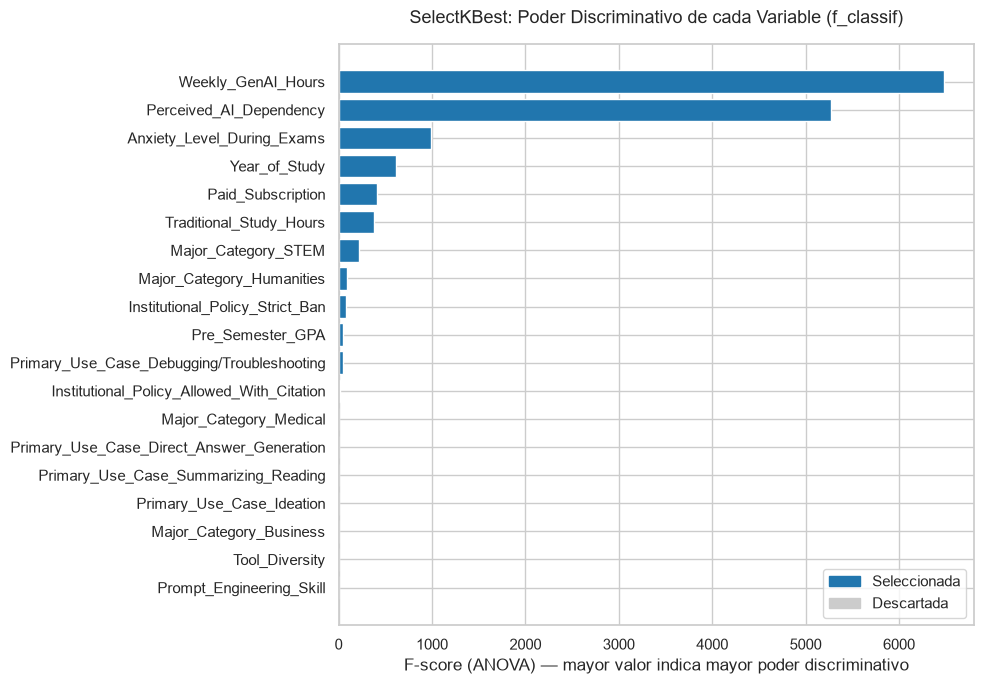

In [18]:
scores_df = pd.DataFrame({
    'Variable':     X_train_enc.columns,
    'F-score':      selector.scores_.round(1),
    'Seleccionada': selector.get_support()
}).sort_values('F-score', ascending=True)

colores_fs = ['#2176ae' if s else '#cccccc' for s in scores_df['Seleccionada']]

plt.figure(figsize=(10, 7))
plt.barh(scores_df['Variable'], scores_df['F-score'], color=colores_fs)
plt.xlabel('F-score (ANOVA) — mayor valor indica mayor poder discriminativo')
plt.title('SelectKBest: Poder Discriminativo de cada Variable (f_classif)', fontsize=13, pad=15)
from matplotlib.patches import Patch
plt.legend(handles=[
    Patch(color='#2176ae', label='Seleccionada'),
    Patch(color='#cccccc', label='Descartada')
], loc='lower right')
plt.tight_layout()
plt.show()

In [19]:
modelo = DecisionTreeClassifier(
    max_depth=5,
    min_samples_leaf=10,
    class_weight='balanced',
    random_state=42
)
modelo.fit(X_train_final, y_train)

print(f'Algoritmo : {type(modelo).__name__}')
print(f'max_depth={modelo.max_depth}  |  min_samples_leaf={modelo.min_samples_leaf}  |  class_weight=balanced')
print(f'Entrenado sobre {X_train_final.shape[1]} variables seleccionadas')

Algoritmo : DecisionTreeClassifier
max_depth=5  |  min_samples_leaf=10  |  class_weight=balanced
Entrenado sobre 12 variables seleccionadas


In [20]:
y_pred_train = modelo.predict(X_train_final)
y_pred_test  = modelo.predict(X_test_final)

acc_train = accuracy_score(y_train, y_pred_train)
acc_test  = accuracy_score(y_test,  y_pred_test)
rec_train = recall_score(y_train, y_pred_train)
rec_test  = recall_score(y_test,  y_pred_test)

print(f'--- ACCURACY ---')
print(f'Train : {acc_train*100:.2f}%')
print(f'Test  : {acc_test*100:.2f}%')
print(f'Dif   : {abs(acc_train-acc_test)*100:.2f} pp')
print(f'\n--- RECALL (Riesgo Alto) ---')
print(f'Train : {rec_train*100:.1f}%')
print(f'Test  : {rec_test*100:.1f}%')

--- ACCURACY ---
Train : 76.32%
Test  : 75.31%
Dif   : 1.01 pp

--- RECALL (Riesgo Alto) ---
Train : 63.0%
Test  : 60.3%


In [21]:
nombres = ['Control (0)', 'Riesgo Alto (1)']

print('=' * 55)
print('REPORTE — CONJUNTO DE ENTRENAMIENTO (TRAIN)')
print('=' * 55)
print(classification_report(y_train, y_pred_train, target_names=nombres))

print('=' * 55)
print('REPORTE — CONJUNTO DE PRUEBA (TEST)')
print('=' * 55)
print(classification_report(y_test, y_pred_test, target_names=nombres))

REPORTE — CONJUNTO DE ENTRENAMIENTO (TRAIN)
                 precision    recall  f1-score   support

    Control (0)       0.87      0.81      0.84     26259
Riesgo Alto (1)       0.52      0.63      0.57      8741

       accuracy                           0.76     35000
      macro avg       0.69      0.72      0.70     35000
   weighted avg       0.78      0.76      0.77     35000

REPORTE — CONJUNTO DE PRUEBA (TEST)
                 precision    recall  f1-score   support

    Control (0)       0.86      0.80      0.83     11254
Riesgo Alto (1)       0.50      0.60      0.55      3746

       accuracy                           0.75     15000
      macro avg       0.68      0.70      0.69     15000
   weighted avg       0.77      0.75      0.76     15000



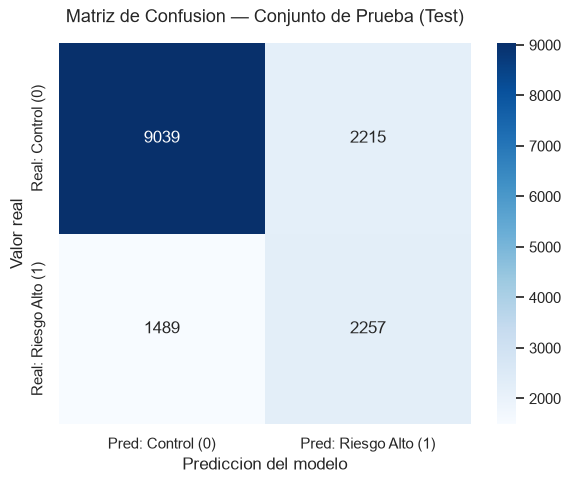

In [22]:
cm = confusion_matrix(y_test, y_pred_test)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Pred: Control (0)', 'Pred: Riesgo Alto (1)'],
            yticklabels=['Real: Control (0)', 'Real: Riesgo Alto (1)'])
plt.title('Matriz de Confusion — Conjunto de Prueba (Test)', fontsize=13, pad=15)
plt.xlabel('Prediccion del modelo')
plt.ylabel('Valor real')
plt.tight_layout()
plt.show()

## Analisis del sobreajuste y eleccion de la metrica principal

Antes de interpretar los resultados, hay que tener en cuenta una cuestion importante: el dataset tiene un desbalance de clases de 75 % (control) contra 25 % (riesgo alto). Esto significa que si el modelo simplemente predijera siempre clase 0 para todos los estudiantes, obtendria un 75 % de accuracy sin haber aprendido absolutamente nada. Por eso la accuracy general no sirve como metrica principal en este contexto.

La metrica que realmente importa aqui es el **recall de la clase 1**: cuantos de los estudiantes que realmente estan en riesgo alto logra detectar el modelo. Un estudiante en riesgo que el modelo clasifica como control (falso negativo) no recibe ninguna atencion ni intervencion. En un sistema de alerta temprana, ese tipo de error tiene consecuencias mucho mas graves que el caso contrario (avisar de mas a alguien que no lo necesita).

Para diagnosticar el sobreajuste se comparan los resultados en train y en test. El parametro `max_depth=5` limita la profundidad del arbol para evitar que memorice los datos de entrenamiento en lugar de aprender patrones generalizables. Una diferencia de accuracy menor a 2 puntos porcentuales entre ambos conjuntos indica que el modelo generaliza bien.

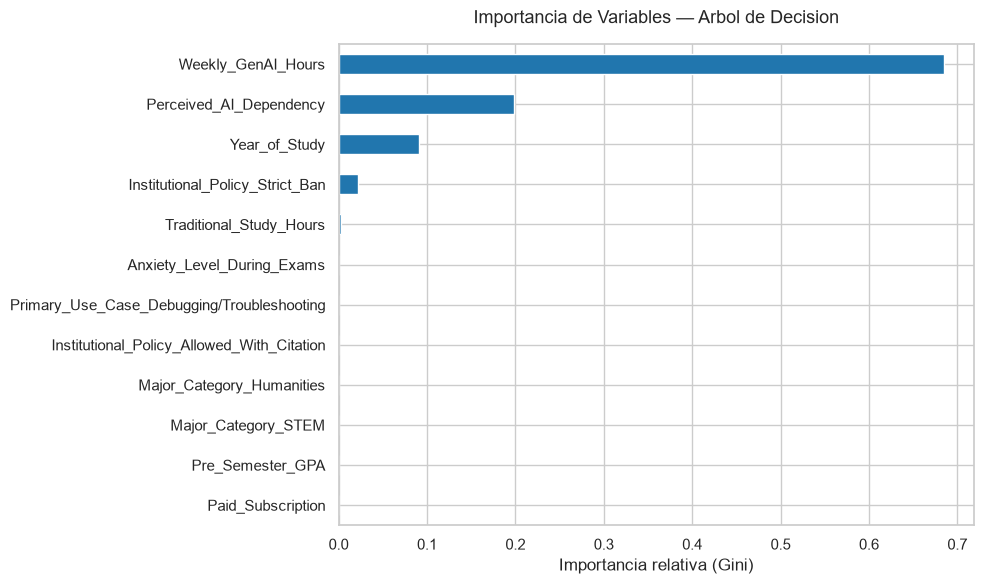

Importancia de variables:
Weekly_GenAI_Hours                            0.6846
Perceived_AI_Dependency                       0.1982
Year_of_Study                                 0.0913
Institutional_Policy_Strict_Ban               0.0222
Traditional_Study_Hours                       0.0031
Anxiety_Level_During_Exams                    0.0008
Paid_Subscription                             0.0000
Pre_Semester_GPA                              0.0000
Major_Category_Humanities                     0.0000
Major_Category_STEM                           0.0000
Primary_Use_Case_Debugging/Troubleshooting    0.0000
Institutional_Policy_Allowed_With_Citation    0.0000


In [23]:
importancias = pd.Series(
    modelo.feature_importances_,
    index=cols_sel
).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
importancias.sort_values().plot(kind='barh', color='#2176ae')
plt.title('Importancia de Variables — Arbol de Decision', fontsize=13, pad=15)
plt.xlabel('Importancia relativa (Gini)')
plt.tight_layout()
plt.show()

print('Importancia de variables:')
print(importancias.round(4).to_string())

## Conclusion General

Este proyecto analizo el riesgo de burnout academico en un dataset real de **50.000 estudiantes** en el contexto del creciente uso de IA generativa en el ambito universitario.

El analisis exploratorio permitio poner a prueba dos hipotesis. La primera proponia que los estudiantes con suscripcion paga a herramientas de IA tendrian mayor riesgo de burnout, lo cual se confirmo de manera parcial: si bien la diferencia no es grande, los datos muestran una tendencia consistente que vale la pena considerar. La segunda hipotesis planteaba que los anos avanzados de la carrera se asociarian con mayor burnout, pero los resultados mostraron una curva no lineal, con los extremos (Freshman y Graduate) siendo los mas vulnerables, no los anos intermedios. Esto resulto bastante llamativo porque desafia la idea intuitiva de que 'a mas anos de carrera, mas agotamiento'.

En cuanto al modelado, se procuro respetar todos los principios metodologicos del pipeline de machine learning:

La **division del dataset** en train (70 %) y test (30 %) se hizo de forma estratificada y fue el primer paso del proceso, antes de cualquier transformacion. Esto garantiza que ningun objeto que se ajuste posteriormente (como el encoder o el selector) tenga acceso a informacion del conjunto de prueba.

Las **variables ordinales** (Year_of_Study, Prompt_Engineering_Skill, Paid_Subscription) se codificaron manualmente con un diccionario de mapeo fijo que respeta su orden semantico, evitando el uso de Label Encoding en variables nominales donde ese orden no existe.

El **One-Hot Encoding** se ajusto exclusivamente sobre X_train y se aplico sobre ambos conjuntos con transform. Lo mismo ocurrio con **SelectKBest**, que se ajusto solo sobre el conjunto de entrenamiento para evitar que la seleccion de variables incorpore informacion del test.

El modelo elegido fue un **Arbol de Decision** con `max_depth=5` para limitar la complejidad y favorecer la generalizacion. El desbalance de clases (75/25) se manejo con `class_weight='balanced'` y la evaluacion se realizo sobre ambos conjuntos, priorizando el **recall de la clase 1** como metrica principal por las razones ya explicadas.

Los resultados muestran que el modelo detecta alrededor del 60 % de los casos reales de riesgo alto, con una diferencia minima entre train y test que indica buena capacidad de generalizacion y ausencia de sobreajuste grave. Si bien hay margen para mejorar (especialmente en la deteccion de falsos negativos), el modelo constituye una base solida para construir un sistema de alerta temprana. Las variables identificadas como mas importantes por el arbol pueden orientar decisiones concretas de las instituciones educativas sobre donde enfocar los esfuerzos de prevencion.